In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [8]:
data = pd.read_csv("D:\BDA_0024\APS_LAB\datasets\Telco-Customer-Churn.csv")

In [9]:
print("Dataset Shape:", data.shape)


Dataset Shape: (7043, 21)


In [10]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [12]:
print("Columns:")

Columns:


In [13]:
print(data.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [14]:
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [15]:
# Convert TotalCharges into numeric format

data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

print(data["TotalCharges"].dtype)

float64


In [16]:
print(data.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [17]:
# Handle missing values

data["TotalCharges"] = data["TotalCharges"].fillna(
    data["TotalCharges"].median()
)


In [18]:
print("Null values after handling:")
print(data.isnull().sum())

Null values after handling:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [20]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [21]:
print(data["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [22]:
print(data["Churn"].value_counts(normalize=True))

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [23]:
# Convert target variable into binary values

data["Churn"] = data["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(data["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [51]:
# Create class distribution table

class_counts = data["Churn"].value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class": ["No Churn", "Churn"],
    "count": class_counts.values,
    "Probability": class_counts.values / len(data)
})

print(class_distribution)

      class  count  Probability
0  No Churn   5174      0.73463
1     Churn   1869      0.26537


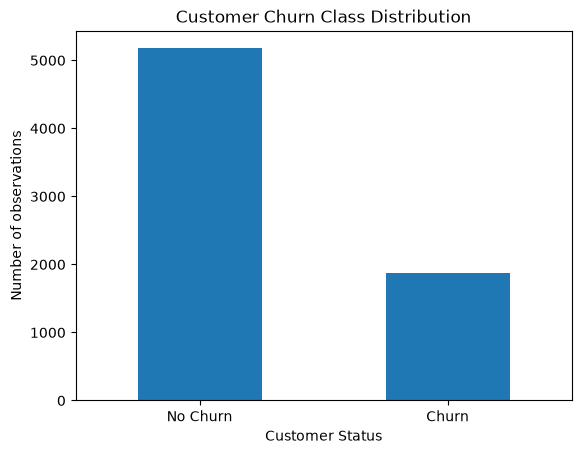

In [52]:
# Plot class distribution

class_distribution.plot(
    x="class",
    y="count",
    kind="bar",
    legend=False
)

plt.ylabel("Number of observations")
plt.xlabel("Customer Status")
plt.title("Customer Churn Class Distribution")
plt.xticks(rotation=0)
plt.show()

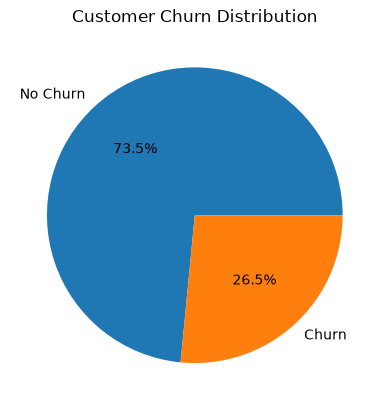

In [53]:
# Plot class distribution as pie chart

class_distribution.plot(
    x="class",
    y="count",
    kind="pie",
    labels=class_distribution["class"],
    autopct="%1.1f%%",
    legend=False
)

plt.ylabel("")
plt.title("Customer Churn Distribution")
plt.show()

In [54]:
# Separate input features and target

X = data.drop(
    columns=["Churn", "customerID"]
)

y = data["Churn"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7043, 19)
Target shape: (7043,)


In [55]:
# Identify numerical and categorical columns

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numerical Features:")
print(numerical_features.tolist())

print("\nCategorical Features:")
print(categorical_features.tolist())

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\bda\AppData\Local\Temp\ipykernel_8492\3862031886.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [56]:
# One-hot encode categorical variables

X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

print("Feature shape after encoding:", X.shape)

X.head()

Feature shape after encoding: (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [57]:
# Final null value check

print("Null values in X:")
print(X.isnull().sum().sum())

print("\nNull values in y:")
print(y.isnull().sum())

Null values in X:
0

Null values in y:
0


In [58]:
# Create training and testing samples

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Size:", len(y_train))
print("Testing Size:", len(y_test))

Training Size: 5634
Testing Size: 1409


In [59]:
# Train Logistic Regression Model

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [60]:
# Make predictions

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [61]:
# Obtain predicted probabilities

probabilities = model.predict_proba(X_test)

print("First 5 probability predictions:")
print(probabilities[:5])

First 5 probability predictions:
[[0.95563487 0.04436513]
 [0.31639994 0.68360006]
 [0.94356046 0.05643954]
 [0.59169375 0.40830625]
 [0.97830853 0.02169147]]


In [62]:
# Create results DataFrame

results = pd.DataFrame({
    "Actual": y_test.values,
    "P_No_Churn": probabilities[:, 0],
    "P_Churn": probabilities[:, 1]
})

results.head(10)

,Actual,P_No_Churn,P_Churn
0,0,0.955635,0.044365
1,0,0.316400,0.683600
2,0,0.943560,0.056440
3,0,0.591694,0.408306
4,0,0.978309,0.021691
5,0,0.395634,0.604366
6,0,0.547279,0.452721
7,0,0.868793,0.131207
8,0,0.997092,0.002908
9,1,0.605752,0.394248


In [63]:
# Convert actual values to labels

results["Actual_label"] = results["Actual"].map({
    0: "No Churn",
    1: "Churn"
})

results["Predicted"] = y_pred

results["Predicted_label"] = results["Predicted"].map({
    0: "No Churn",
    1: "Churn"
})

results.head(10)

,Actual,P_No_Churn,P_Churn,Actual_label,Predicted,Predicted_label
0,0,0.955635,0.044365,No Churn,0,No Churn
1,0,0.316400,0.683600,No Churn,1,Churn
2,0,0.943560,0.056440,No Churn,0,No Churn
3,0,0.591694,0.408306,No Churn,0,No Churn
4,0,0.978309,0.021691,No Churn,0,No Churn
5,0,0.395634,0.604366,No Churn,1,Churn
6,0,0.547279,0.452721,No Churn,0,No Churn
7,0,0.868793,0.131207,No Churn,0,No Churn
8,0,0.997092,0.002908,No Churn,0,No Churn
9,1,0.605752,0.394248,Churn,0,No Churn


In [64]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8069552874378992
Accuracy (%): 80.69552874378992


In [65]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[925 110]
 [162 212]]


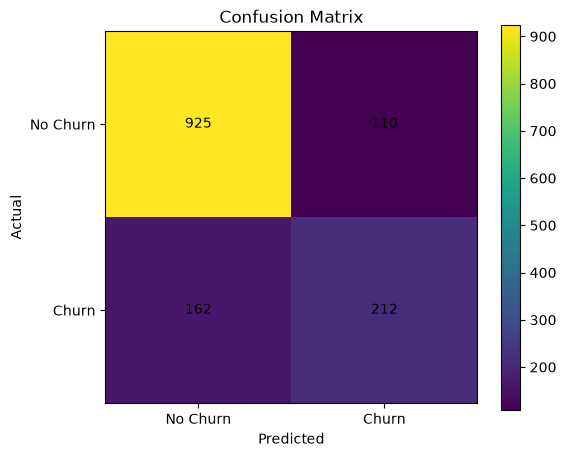

In [66]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["No Churn", "Churn"]
)

plt.yticks(
    [0, 1],
    ["No Churn", "Churn"]
)

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [67]:
# Evaluation metrics

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.6583850931677019
Recall: 0.5668449197860963
F1 Score: 0.6091954022988506


In [68]:
# Classification Report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [69]:
# Compare different classification thresholds

thresholds = [0.10, 0.30, 0.50, 0.70, 0.90]

metrics_data = []

for threshold in thresholds:

    predicted_churn = (
        probabilities[:, 1] >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_test,
        predicted_churn,
        labels=[0, 1]
    )

    TN, FP, FN, TP = cm.ravel()

    metrics_data.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            predicted_churn
        ),
        "Precision": precision_score(
            y_test,
            predicted_churn,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predicted_churn,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test,
            predicted_churn,
            zero_division=0
        ),
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TP": TP
    })

threshold_metrics = pd.DataFrame(metrics_data)

threshold_metrics.round(3)

,Threshold,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP
0,0.1,0.618,0.406,0.947,0.568,517,518,20,354
1,0.3,0.749,0.518,0.754,0.614,773,262,92,282
2,0.5,0.807,0.658,0.567,0.609,925,110,162,212
3,0.7,0.764,0.730,0.174,0.281,1011,24,309,65
4,0.9,0.735,0.000,0.000,0.000,1035,0,374,0


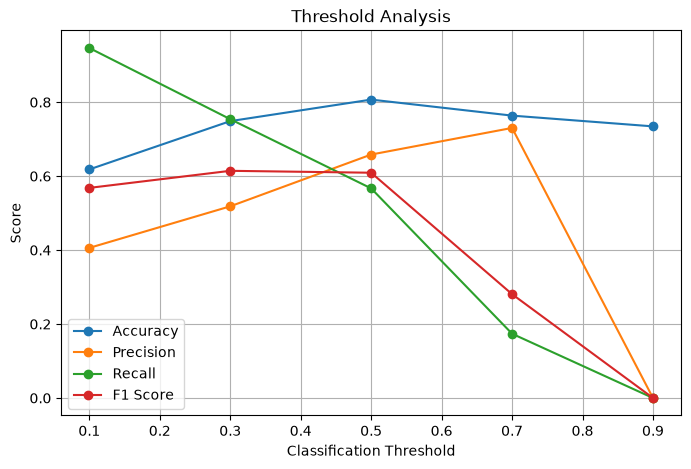

In [70]:
# Plot threshold performance

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_metrics["Threshold"],
    threshold_metrics["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    threshold_metrics["Threshold"],
    threshold_metrics["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_metrics["Threshold"],
    threshold_metrics["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_metrics["Threshold"],
    threshold_metrics["F1-score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.legend()
plt.grid(True)

plt.show()

In [71]:
# Final model evaluation
      
print("========== LOGISTIC REGRESSION RESULTS ==========")      
      
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

========== LOGISTIC REGRESSION RESULTS ==========
Accuracy : 0.8069552874378992
Precision: 0.6583850931677019
Recall   : 0.5668449197860963
F1 Score : 0.6091954022988506

Confusion Matrix:
[[925 110]
 [162 212]]


In [74]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability of positive class (Churn = 1)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.8415846443979436


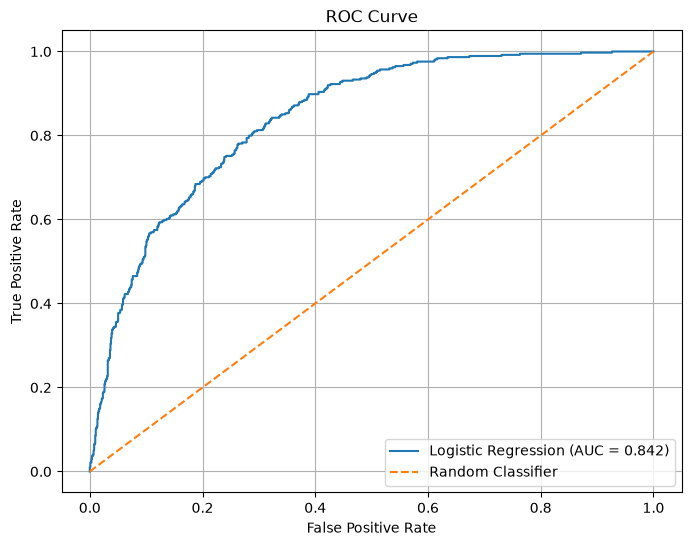

In [75]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

Logistic Regression was successfully applied to the Telco
Customer Churn dataset without using SMOTE.

The model was trained on the original imbalanced training data.
The performance was evaluated using Accuracy, Precision, Recall,
F1 Score and ROC-AUC.

Since the Churn class is the minority class, the model may have
lower Recall for detecting customers who are likely to churn.
Therefore, Accuracy alone should not be used to judge the model.
Recall, F1 Score and ROC-AUC are also important for evaluating
churn prediction performance.